# Sales & Inventory Analysis and Forecasting
## End-to-end pipeline: data loading, data quality checks (EDA), rule-based cleaning, anomaly detection, monthly aggregation, 6-month forecasting per product category, and inventory planning.

**Design principle:** every cleaning step is a *rule written in code*, never a hand-edited row. The same notebook should work unchanged if the file had 238 rows or 2.38 million rows.

# Important libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 20)
sns.set_style("whitegrid")

FILE = "Sales_Inventory_Dataset.xlsx"
FORECAST_HORIZON = 6          # months to forecast
MA_WINDOW = 3                 # window for the moving-average baseline

# 1. Load the data

In [2]:
sales = pd.read_excel(FILE, sheet_name="sales")
inventory = pd.read_excel(FILE, sheet_name="inventory")

print("sales     :", sales.shape)
print("inventory :", inventory.shape)
sales.head(8)

sales     : (238, 8)
inventory : (7, 3)


,order_id,order_date,product_id,product_name,quantity,sold_price,customer_id,region
0,101,2025-01-01,ST01,black pen,1,5,C001,EAST
1,102,2025-01-02,ST02,pencil,5,10,C005,WEST
2,103,2025-01-03,ST03,blue pen,20,60,C004,WEST
3,104,2025-01-04,ST03,blue pen,8,24,C125,NORTH
4,105,2025-01-05,ST04,red pen,3,15,C475,EAST
5,106,2025-01-06,ST02,pencil,7,14,C058,WEST
6,107,2025-01-07,ST02,pencil,10,20,C146,SOUTH
7,108,2025-01-08,ST05,eraser,15,30,C225,EAST


In [3]:
inventory

,product_id,product_name,quantity_on_hand
0,ST01,black pen,75
1,ST02,pencil,85
2,ST03,blue pen,97
3,ST04,red pen,46
4,ST05,eraser,105
5,ST06,scale,5
6,ST07,sharpener,25


# 2. Data quality checks (EDA) and anomalies
## 2.1 Structure, missing values and duplicates

In [4]:
sales.info()

<class 'pandas.DataFrame'>
RangeIndex: 238 entries, 0 to 237
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   order_id      238 non-null    int64         
 1   order_date    238 non-null    datetime64[us]
 2   product_id    237 non-null    str           
 3   product_name  237 non-null    str           
 4   quantity      238 non-null    int64         
 5   sold_price    238 non-null    int64         
 6   customer_id   235 non-null    str           
 7   region        238 non-null    str           
dtypes: datetime64[us](1), int64(3), str(4)
memory usage: 15.0 KB


In [5]:
sales.describe()

,order_id,order_date,quantity,sold_price
count,238.000000,238,238.000000,238.000000
mean,219.500000,2025-04-29 12:00:00,7.105042,27.747899
min,101.000000,2025-01-01 00:00:00,1.000000,2.000000
25%,160.250000,2025-03-01 06:00:00,4.000000,10.000000
50%,219.500000,2025-04-29 12:00:00,6.000000,20.000000
75%,278.750000,2025-06-27 18:00:00,8.000000,40.000000
max,338.000000,2025-08-26 00:00:00,20.000000,200.000000
std,68.848868,NaN,5.124762,29.294581


In [6]:
missing = sales.isnull().sum().to_frame("missing_count")
missing["missing_pct"] = (missing["missing_count"] / len(sales) * 100).round(2)
missing[missing["missing_count"] > 0]

,missing_count,missing_pct
product_id,1,0.42
product_name,1,0.42
customer_id,3,1.26


In [7]:
print("Fully duplicated rows :", sales.duplicated().sum())
print("Duplicated order_id   :", sales["order_id"].duplicated().sum())
print("Zero/negative quantity:", (sales["quantity"] <= 0).sum())
print("Zero/negative price   :", (sales["sold_price"] <= 0).sum())

Fully duplicated rows : 0
Duplicated order_id   : 0
Zero/negative quantity: 0
Zero/negative price   : 0


## 2.2 Consistency checks
These are generic checks: they do not depend on knowing the data in advance.

In [8]:
# Text columns: stray spaces or mixed case would create fake "new" categories
for col in ["product_id", "product_name", "customer_id", "region"]:
    raw = sales[col].dropna().nunique()
    clean = sales[col].dropna().str.strip().str.lower().nunique()
    print(f"{col:13s} unique: {raw}  | after strip/lower: {clean}")

product_id    unique: 7  | after strip/lower: 7
product_name  unique: 7  | after strip/lower: 7
customer_id   unique: 8  | after strip/lower: 8
region        unique: 4  | after strip/lower: 4


In [9]:
# product_id <-> product_name must be a 1-to-1 mapping
id_name = sales.dropna(subset=["product_id", "product_name"])
print("names per id :", id_name.groupby("product_id")["product_name"].nunique().max())
print("ids per name :", id_name.groupby("product_name")["product_id"].nunique().max())

names per id : 1
ids per name : 1


In [10]:
# sold_price is the LINE TOTAL (revenue), not a unit price.
# Each product should sell at one consistent unit price.
sales["unit_price"] = sales["sold_price"] / sales["quantity"]
sales.groupby("product_name")["unit_price"].agg(["min", "max", "nunique"])

,min,max,nunique
product_name,,,
black pen,5.0,5.0,1
blue pen,3.0,3.0,1
eraser,2.0,2.0,1
pencil,2.0,2.0,1
red pen,5.0,5.0,1
scale,10.0,10.0,1
sharpener,5.0,5.0,1


In [11]:
# Order ids and dates: gaps, orders per day, partial periods
print("order_id steps   :", sales["order_id"].diff().value_counts().to_dict())
print("date range       :", sales["order_date"].min().date(), "->", sales["order_date"].max().date())
print("orders per day   :", sales.groupby("order_date").size().value_counts().to_dict())

full_days = pd.date_range(sales["order_date"].min(), sales["order_date"].max(), freq="D")
print("days with no order:", len(full_days.difference(sales["order_date"])))

last_date = sales["order_date"].max()
days_in_last_month = last_date.days_in_month
print(f"last month observed: {last_date.day} of {days_in_last_month} days  -> partial month")

order_id steps   : {1.0: 237}
date range       : 2025-01-01 -> 2025-08-26
orders per day   : {1: 238}
days with no order: 0
last month observed: 26 of 31 days  -> partial month


In [12]:
# Product life cycle: when did each product first and last sell?
life = sales.dropna(subset=["product_name"]).groupby("product_name")["order_date"].agg(first_sale="min", last_sale="max")
life["days_since_last_sale"] = (sales["order_date"].max() - life["last_sale"]).dt.days
life.sort_values("first_sale")

,first_sale,last_sale,days_since_last_sale
product_name,,,
black pen,2025-01-01,2025-08-25,1
pencil,2025-01-02,2025-08-26,0
blue pen,2025-01-03,2025-08-18,8
red pen,2025-01-05,2025-08-19,7
eraser,2025-01-08,2025-08-22,4
scale,2025-01-10,2025-06-04,83
sharpener,2025-06-05,2025-08-24,2


In [13]:
# Repeating patterns: a high match between a column and itself shifted by k rows
def best_lag_match(series, max_lag=60):
    scores = {}
    for k in range(1, max_lag + 1):
        a, b = series.iloc[k:].values, series.iloc[:-k].values
        mask = pd.notna(a) & pd.notna(b)
        scores[k] = (a[mask] == b[mask]).mean()
    k = max(scores, key=scores.get)
    return k, round(scores[k] * 100, 1)

for col in ["customer_id", "quantity", "region", "product_name"]:
    k, pct = best_lag_match(sales[col])
    print(f"{col:13s} repeats every {k:2d} rows in {pct}% of cases")

customer_id   repeats every 20 rows in 91.1% of cases
quantity      repeats every 14 rows in 93.8% of cases
region        repeats every  7 rows in 91.3% of cases
product_name  repeats every 11 rows in 70.7% of cases


## 2.3 Anomaly detection (rule-based, per product)
A global outlier test on `sold_price` flags every scale order, because scales simply cost more (₹10 vs ₹2–5). That is a feature of the product, not an anomaly.
The right comparison is **within each product**:
* unit price different from that product's usual price
* quantity unusually high/low for that product (IQR rule, per product)

In [14]:
med_price = sales.groupby("product_name")["unit_price"].transform("median")
sales["flag_price_mismatch"] = (sales["unit_price"] - med_price).abs() > 0.01

q1 = sales.groupby("product_name")["quantity"].transform(lambda s: s.quantile(0.25))
q3 = sales.groupby("product_name")["quantity"].transform(lambda s: s.quantile(0.75))
iqr = q3 - q1
sales["flag_qty_outlier"] = (sales["quantity"] > q3 + 1.5 * iqr) | (sales["quantity"] < q1 - 1.5 * iqr)

print("unit-price mismatches :", sales["flag_price_mismatch"].sum())
print("quantity outliers     :", sales["flag_qty_outlier"].sum())
sales[sales["flag_qty_outlier"]][["order_id", "order_date", "product_name", "quantity", "sold_price", "region"]]

unit-price mismatches : 0
quantity outliers     : 24


,order_id,order_date,product_name,quantity,sold_price,region
2,103,2025-01-03,blue pen,20,60,WEST
16,117,2025-01-17,pencil,20,40,WEST
21,122,2025-01-22,scale,15,150,EAST
30,131,2025-01-31,eraser,20,40,WEST
44,145,2025-02-14,black pen,20,100,WEST
58,159,2025-02-28,blue pen,20,60,WEST
72,173,2025-03-14,pencil,20,40,WEST
77,178,2025-03-19,black pen,15,75,EAST
86,187,2025-03-28,scale,20,200,WEST
100,201,2025-04-11,pencil,20,40,WEST


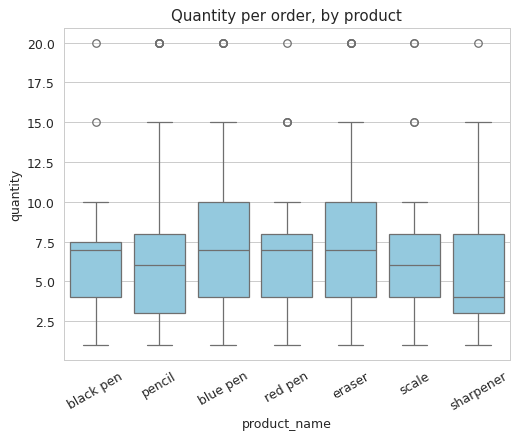

In [15]:
sns.boxplot(data=sales, x="product_name", y="quantity", color="skyblue")
plt.title("Quantity per order, by product")
plt.xticks(rotation=30)
plt.show()

# 3. Handling missing values with rules (no manual row edits)
## 3.1 Product: recover from the data itself
1. If only one of `product_id` / `product_name` is missing, fill it from the 1-to-1 mapping.
2. If both are missing, use the unit price **only when that price belongs to exactly one product**. Prices shared by several products (₹2 = pencil and eraser, ₹5 = three products) cannot identify the product, so those rows become `Unknown`.
3. Every filled value gets a flag column, so the change is auditable.

In [16]:
clean = sales.copy()
clean["product_imputed"] = clean["product_id"].isna() | clean["product_name"].isna()

# Rule 1: fill each column from the other using the observed mapping
valid = clean.dropna(subset=["product_id", "product_name"])
id_to_name = valid.drop_duplicates("product_id").set_index("product_id")["product_name"]
name_to_id = valid.drop_duplicates("product_name").set_index("product_name")["product_id"]
clean["product_name"] = clean["product_name"].fillna(clean["product_id"].map(id_to_name))
clean["product_id"] = clean["product_id"].fillna(clean["product_name"].map(name_to_id))

# Rule 2: unit price -> product, only for prices unique to one product
price_products = valid.groupby("unit_price")["product_name"].unique()
unique_price_map = price_products[price_products.apply(len) == 1].apply(lambda names: names[0])

need = clean["product_name"].isna()
clean.loc[need, "product_name"] = clean.loc[need, "unit_price"].map(unique_price_map)
clean["product_id"] = clean["product_id"].fillna(clean["product_name"].map(name_to_id))

# Anything still unresolved is honestly unknown
clean[["product_id", "product_name"]] = clean[["product_id", "product_name"]].fillna("Unknown")

print("Price -> product map (unique prices only):", unique_price_map.to_dict())
clean[clean["product_imputed"]][["order_id", "quantity", "sold_price", "unit_price", "product_id", "product_name"]]

Price -> product map (unique prices only): {3.0: 'blue pen', 10.0: 'scale'}


,order_id,quantity,sold_price,unit_price,product_id,product_name
112,213,1,3,3.0,ST03,blue pen


## 3.2 Customer: do not guess, label as unknown
`customer_id` cannot be derived from any other column. The sequence does repeat roughly every 20 rows, but only in ~91% of cases, and for one missing row the row 20 before and the row 20 after point to **different** customers. Guessing would invent data.
Customer is not needed for the sales forecast, so the honest fix is `UNKNOWN` plus a flag.

In [17]:
lag = 20
for i in clean.index[clean["customer_id"].isna()]:
    before = clean["customer_id"].get(i - lag)
    after = clean["customer_id"].get(i + lag)
    print(f"row {i}: {lag} rows before -> {before}, {lag} rows after -> {after}")

row 11: 20 rows before -> None, 20 rows after -> C058
row 191: 20 rows before -> C058, 20 rows after -> C146
row 228: 20 rows before -> C125, 20 rows after -> None


In [18]:
clean["customer_imputed"] = clean["customer_id"].isna()
clean["customer_id"] = clean["customer_id"].fillna("UNKNOWN")
clean.isnull().sum()

order_id               0
order_date             0
product_id             0
product_name           0
quantity               0
sold_price             0
customer_id            0
region                 0
unit_price             0
flag_price_mismatch    0
flag_qty_outlier       0
product_imputed        0
customer_imputed       0
dtype: int64

# 4. Exploratory analysis

In [19]:
product_summary = (clean.groupby("product_name")
                   .agg(orders=("order_id", "count"),
                        units=("quantity", "sum"),
                        revenue=("sold_price", "sum"),
                        unit_price=("unit_price", "median"))
                   .sort_values("revenue", ascending=False))
product_summary["revenue_share_%"] = (product_summary["revenue"] / product_summary["revenue"].sum() * 100).round(1)
product_summary

,orders,units,revenue,unit_price,revenue_share_%
product_name,,,,,
scale,29,199,1990,10.0,30.1
blue pen,43,331,993,3.0,15.0
pencil,67,442,884,2.0,13.4
red pen,22,167,835,5.0,12.6
black pen,23,153,765,5.0,11.6
eraser,36,286,572,2.0,8.7
sharpener,18,113,565,5.0,8.6


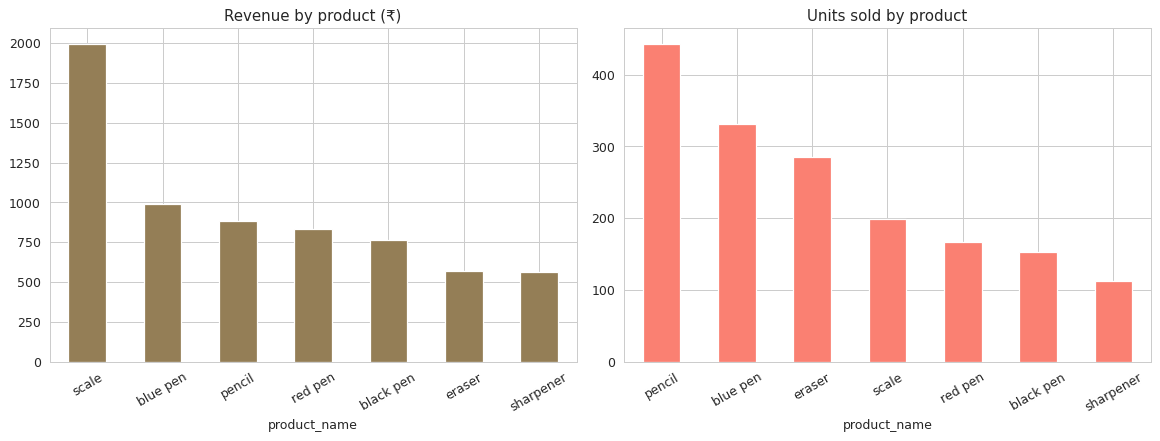

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
product_summary["revenue"].plot(kind="bar", ax=axes[0], color="#947E56", title="Revenue by product (₹)")
product_summary["units"].sort_values(ascending=False).plot(kind="bar", ax=axes[1], color="salmon", title="Units sold by product")
for ax in axes:
    ax.tick_params(axis="x", rotation=30)
plt.tight_layout()
plt.show()

In [21]:
region_summary = clean.groupby("region").agg(revenue=("sold_price", "sum"), units=("quantity", "sum")).sort_values("revenue", ascending=False)
region_summary["revenue_share_%"] = (region_summary["revenue"] / region_summary["revenue"].sum() * 100).round(1)
region_summary

,revenue,units,revenue_share_%
region,,,
WEST,3089,785,46.8
EAST,1805,488,27.3
SOUTH,995,218,15.1
NORTH,715,200,10.8


In [22]:
clean.groupby("customer_id")["sold_price"].sum().sort_values(ascending=False)

customer_id
C058       974
C005       921
C125       905
C004       896
C475       880
C146       715
C001       611
C225       602
UNKNOWN    100
Name: sold_price, dtype: int64

# 5. Build the monthly series (and fill missing periods)
The question asks for monthly sales at category level, so aggregate units to **product x month**.
* A product with no sales in a month is a real zero, so missing product-months are filled with **0** (not interpolated).
* The last month is partial, so it is scaled to a full month before modelling; otherwise the model reads it as a drop in demand.

In [23]:
clean["month"] = clean["order_date"].dt.to_period("M")

monthly_units = clean.pivot_table(index="month", columns="product_name",
                                  values="quantity", aggfunc="sum", fill_value=0)

all_months = pd.period_range(monthly_units.index.min(), monthly_units.index.max(), freq="M")
monthly_units = monthly_units.reindex(all_months, fill_value=0)

days_observed = clean.groupby("month")["order_date"].apply(lambda d: d.dt.day.max())
days_in_month = pd.Series([m.days_in_month for m in monthly_units.index], index=monthly_units.index)
scale = (days_in_month / days_observed).round(4)
print("scaling factor per month:\n", scale)

monthly_units_adj = monthly_units.mul(scale, axis=0)
monthly_units_adj.round(1)

scaling factor per month:
 2025-01    1.0000
2025-02    1.0000
2025-03    1.0000
2025-04    1.0000
2025-05    1.0000
2025-06    1.0000
2025-07    1.0000
2025-08    1.1923
Freq: M, dtype: float64


product_name,black pen,blue pen,eraser,pencil,red pen,scale,sharpener
2025-01,6.0,43.0,51.0,70.0,16.0,38.0,0.0
2025-02,31.0,51.0,25.0,45.0,17.0,29.0,0.0
2025-03,24.0,25.0,42.0,59.0,13.0,53.0,0.0
2025-04,13.0,42.0,37.0,73.0,28.0,30.0,0.0
2025-05,25.0,37.0,39.0,50.0,25.0,36.0,0.0
2025-06,19.0,54.0,20.0,28.0,23.0,13.0,53.0
2025-07,16.0,51.0,34.0,58.0,34.0,0.0,28.0
2025-08,22.7,33.4,45.3,70.3,13.1,0.0,38.2


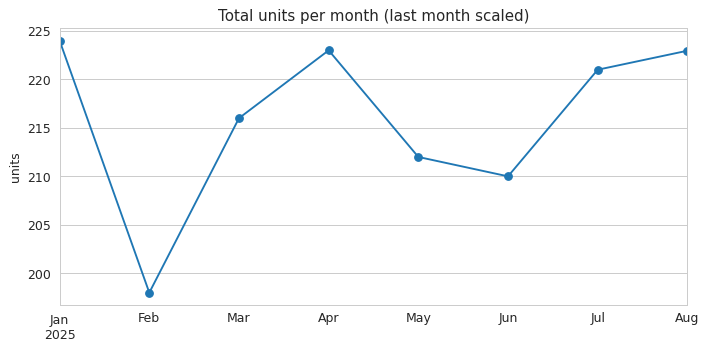

In [24]:
monthly_units_adj.sum(axis=1).plot(marker="o", figsize=(9, 4), title="Total units per month (last month scaled)")
plt.ylabel("units")
plt.show()

### Product life cycle matters
* **Sharpener** was launched in June. The zeros before launch are not "low demand", so its series starts at its first sale.
* **Scale** has had no sales since late June, while only 5 units are in stock. That is either a discontinued product or a **stock-out hiding real demand** (lost sales). The data alone cannot tell which, so it is flagged for a business decision.

In [25]:
first_month = (monthly_units_adj > 0).idxmax()        # first month with sales, per product
def product_history(product):
    s = monthly_units_adj[product]
    return s[s.index >= first_month[product]]

for p in monthly_units_adj.columns:
    print(f"{p:10s} history used from {first_month[p]}  ({len(product_history(p))} months)")

black pen  history used from 2025-01  (8 months)
blue pen   history used from 2025-01  (8 months)
eraser     history used from 2025-01  (8 months)
pencil     history used from 2025-01  (8 months)
red pen    history used from 2025-01  (8 months)
scale      history used from 2025-01  (8 months)
sharpener  history used from 2025-06  (3 months)


# 6. Forecasting the next 6 months per product
## Which model fits this data?
Each product has only **8 monthly points** (7 full months + 1 partial). With so little history:
* **Prophet, SARIMA, Holt-Winters, LSTM** cannot learn seasonality or trend reliably; they need 2+ years of monthly data.
* Suitable models are the simple, robust ones: **Naive**, **3-month moving average** (asked in the question), and **Simple Exponential Smoothing (SES)**.

We pick the model with evidence: a **walk-forward backtest**, where each model forecasts a month it has not seen, and we compare errors using **WAPE** (total absolute error / total actual). MAPE is avoided because it explodes on small values.

In [26]:
def forecast_naive(history, h):
    return np.repeat(history[-1], h)

def forecast_moving_average(history, h, window=MA_WINDOW):
    values = list(history)
    preds = []
    for _ in range(h):
        nxt = np.mean(values[-window:])
        preds.append(nxt)
        values.append(nxt)          # recursive: forecasts feed the next average
    return np.array(preds)

def forecast_ses(history, h, alphas=np.linspace(0.05, 0.95, 19)):
    """Simple Exponential Smoothing; alpha chosen by lowest one-step-ahead squared error.
    Same model as statsmodels SimpleExpSmoothing, written out so the logic is visible."""
    history = np.asarray(history, dtype=float)
    best_alpha, best_sse = None, np.inf
    for a in alphas:
        level, sse = history[0], 0.0
        for y in history[1:]:
            sse += (y - level) ** 2
            level = a * y + (1 - a) * level
        if sse < best_sse:
            best_alpha, best_sse = a, sse
    level = history[0]
    for y in history[1:]:
        level = best_alpha * y + (1 - best_alpha) * level
    return np.repeat(level, h)

MODELS = {"Naive": forecast_naive,
          "3-Month MA": forecast_moving_average,
          "SES": forecast_ses}

In [27]:
def walk_forward_backtest(products, models, min_train=4):
    rows = []
    for product in products:
        hist = product_history(product)
        y = hist.values
        for t in range(min_train, len(y)):           # products with short history are skipped
            for name, fn in models.items():
                pred = fn(y[:t], 1)[0]
                rows.append({"product": product, "month": hist.index[t],
                             "model": name, "actual": y[t], "forecast": pred})
    return pd.DataFrame(rows)

bt = walk_forward_backtest(monthly_units_adj.columns, MODELS)
bt["abs_error"] = (bt["actual"] - bt["forecast"]).abs()

def wape(g):
    return g["abs_error"].sum() / g["actual"].sum() * 100

overall = bt.groupby("model").apply(wape, include_groups=False).sort_values().round(1)
print("Backtest WAPE (%) across all products:\n", overall)

Backtest WAPE (%) across all products:
 model
3-Month MA    35.7
SES           37.7
Naive         37.9
dtype: float64


In [28]:
per_product = bt.groupby(["product", "model"]).apply(wape, include_groups=False).unstack().round(1)
per_product

model,3-Month MA,Naive,SES
product,,,
black pen,11.7,33.5,22.4
blue pen,24.1,24.3,20.1
eraser,28.9,33.5,27.3
pencil,36.0,42.3,40.8
red pen,31.1,38.8,38.1
scale,144.2,85.7,141.3


In [29]:
BEST_MODEL = overall.idxmin()
print("Selected model:", BEST_MODEL)

Selected model: 3-Month MA


## 6.1 Final 6-month forecast (units and revenue)
Prices are constant per product, so revenue = forecast units x unit price. Forecasting units first is better for inventory planning.

In [30]:
future_months = pd.period_range(monthly_units_adj.index.max() + 1, periods=FORECAST_HORIZON, freq="M")
unit_price = clean.groupby("product_name")["unit_price"].median()

def build_forecast(model_name):
    fc = pd.DataFrame({p: MODELS[model_name](product_history(p).values, FORECAST_HORIZON)
                       for p in monthly_units_adj.columns}, index=future_months)
    return fc.round(1)

fc_units_best = build_forecast(BEST_MODEL)
fc_units_ma = build_forecast("3-Month MA")

fc_revenue_best = fc_units_best.mul(unit_price, axis=1).round(0)

print(f"Forecast units per month ({BEST_MODEL}):")
fc_units_best

Forecast units per month (3-Month MA):


,black pen,blue pen,eraser,pencil,red pen,scale,sharpener
2025-09,19.2,46.1,33.1,52.1,23.4,4.3,39.7
2025-10,19.3,43.5,37.5,60.2,23.5,1.4,35.3
2025-11,20.4,41.0,38.6,60.9,20.0,1.9,37.7
2025-12,19.6,43.5,36.4,57.7,22.3,2.6,37.6
2026-01,19.8,42.7,37.5,59.6,21.9,2.0,36.9
2026-02,19.9,42.4,37.5,59.4,21.4,2.2,37.4


In [31]:
print(f"Forecast revenue per month in ₹ ({BEST_MODEL}):")
fc_revenue_best.assign(TOTAL=fc_revenue_best.sum(axis=1))

Forecast revenue per month in ₹ (3-Month MA):


,black pen,blue pen,eraser,pencil,red pen,scale,sharpener,TOTAL
2025-09,96.0,138.0,66.0,104.0,117.0,43.0,198.0,762.0
2025-10,96.0,130.0,75.0,120.0,118.0,14.0,176.0,729.0
2025-11,102.0,123.0,77.0,122.0,100.0,19.0,188.0,731.0
2025-12,98.0,130.0,73.0,115.0,112.0,26.0,188.0,742.0
2026-01,99.0,128.0,75.0,119.0,110.0,20.0,184.0,735.0
2026-02,100.0,127.0,75.0,119.0,107.0,22.0,187.0,737.0


In [32]:
fc_units_ses = build_forecast("SES")
comparison = pd.DataFrame({
    "3-Month MA (units, 6m)": fc_units_ma.sum(),
    "SES (units, 6m)": fc_units_ses.sum(),
    f"Revenue ₹, 6m ({BEST_MODEL})": fc_revenue_best.sum(),
}).round(0)
comparison.loc["TOTAL"] = comparison.sum()
comparison

,"3-Month MA (units, 6m)","SES (units, 6m)","Revenue ₹, 6m (3-Month MA)"
black pen,118.0,121.0,591.0
blue pen,259.0,256.0,776.0
eraser,221.0,226.0,441.0
pencil,350.0,350.0,699.0
red pen,132.0,128.0,664.0
scale,14.0,7.0,144.0
sharpener,225.0,229.0,1121.0
TOTAL,1319.0,1317.0,4436.0


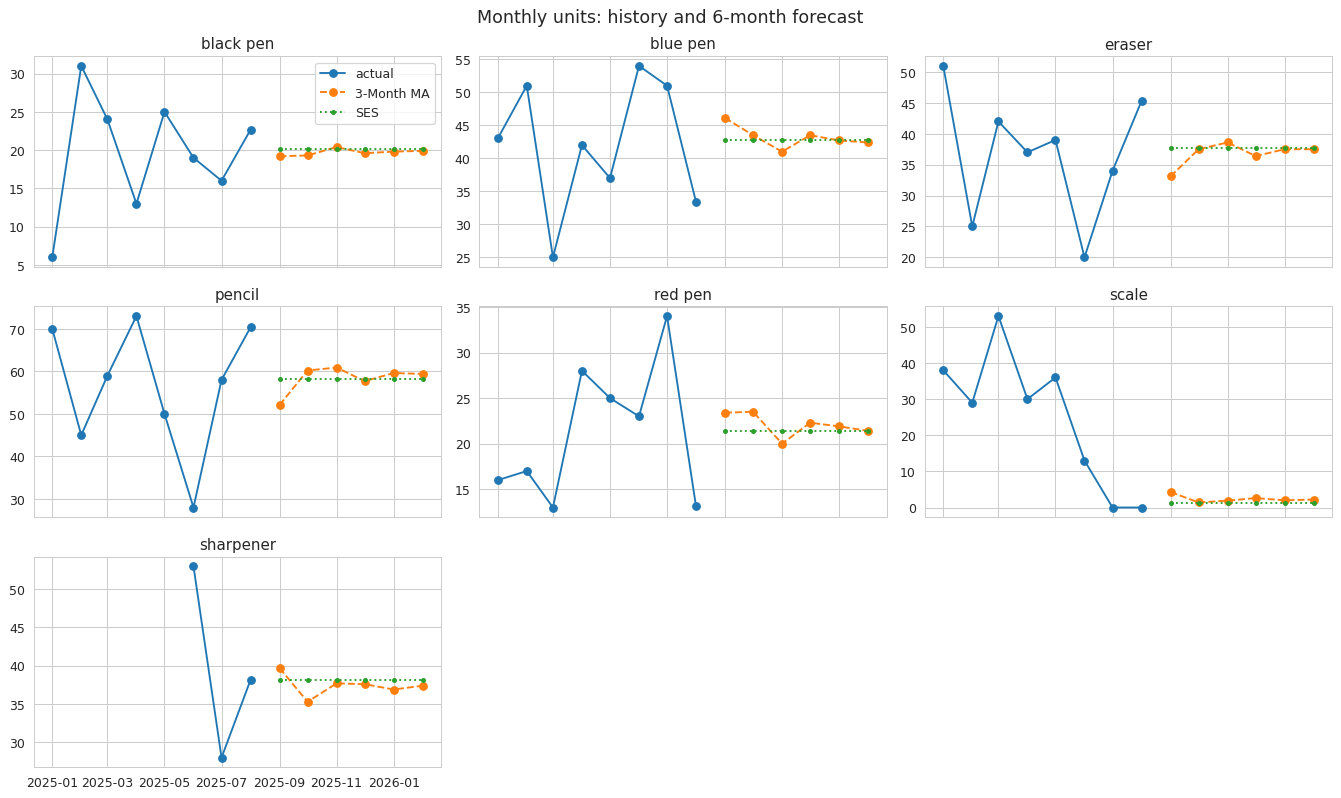

In [33]:
products = monthly_units_adj.columns
fig, axes = plt.subplots(int(np.ceil(len(products) / 3)), 3, figsize=(15, 9), sharex=True)
for ax, p in zip(axes.flat, products):
    hist = product_history(p)
    ax.plot(hist.index.to_timestamp(), hist.values, marker="o", label="actual")
    ax.plot(fc_units_ma.index.to_timestamp(), fc_units_ma[p], marker="o", linestyle="--", label="3-Month MA")
    ax.plot(fc_units_ses.index.to_timestamp(), fc_units_ses[p], marker=".", linestyle=":", label="SES")
    ax.set_title(p)
for ax in list(axes.flat)[len(products):]:
    ax.axis("off")
axes.flat[0].legend()
fig.suptitle("Monthly units: history and 6-month forecast", fontsize=14)
plt.tight_layout()
plt.show()

# 7. Inventory planning
Compare stock on hand with forecast demand: months of cover, the month stock runs out, and how much to reorder to cover the forecast horizon.

In [34]:
inv = inventory.set_index("product_name")[["product_id", "quantity_on_hand"]].copy()
monthly_demand = fc_units_best.mean()
inv["forecast_monthly_units"] = monthly_demand.round(1)
inv["months_of_cover"] = (inv["quantity_on_hand"] / inv["forecast_monthly_units"]).round(1)

cum_demand = fc_units_best.cumsum()
def stockout_month(p):
    over = cum_demand.index[cum_demand[p] > inv.loc[p, "quantity_on_hand"]]
    return str(over[0]) if len(over) else f"after {future_months[-1]}"
inv["stock_out_month"] = [stockout_month(p) for p in inv.index]
inv["reorder_units_for_6m"] = (fc_units_best.sum() - inv["quantity_on_hand"]).clip(lower=0).round(0)
inv.sort_values("months_of_cover")

,product_id,quantity_on_hand,forecast_monthly_units,months_of_cover,stock_out_month,reorder_units_for_6m
product_name,,,,,,
sharpener,ST07,25,37.4,0.7,2025-09,200.0
pencil,ST02,85,58.3,1.5,2025-10,265.0
scale,ST06,5,2.4,2.1,2025-10,9.0
red pen,ST04,46,22.1,2.1,2025-10,86.0
blue pen,ST03,97,43.2,2.2,2025-11,162.0
eraser,ST05,105,36.8,2.9,2025-11,116.0
black pen,ST01,75,19.7,3.8,2025-12,43.0


# 8. Export results

In [35]:
clean.drop(columns=["month"]).to_csv("sales_clean.csv", index=False)
fc_units_best.to_csv("forecast_units_6m.csv")
fc_revenue_best.to_csv("forecast_revenue_6m.csv")
inv.to_csv("inventory_plan.csv")
print("Saved: sales_clean.csv, forecast_units_6m.csv, forecast_revenue_6m.csv, inventory_plan.csv")

Saved: sales_clean.csv, forecast_units_6m.csv, forecast_revenue_6m.csv, inventory_plan.csv


# 9. Summary of data anomalies found
* **Missing values:** 1 row with no product (recovered from its unique ₹3 unit price as blue pen, flagged), 3 rows with no customer (labelled `UNKNOWN`, flagged).
* **Partial last month:** August has 26 of 31 days; raw monthly totals understate August demand.
* **Synthetic regularity:** exactly one order every day, consecutive order ids, and columns that repeat on fixed cycles (quantity every 14 rows, region every 7, customer every 20). Real sales data does not look like this; it suggests generated data, so forecasts should be read as an exercise.
* **Product life cycle:** sharpener first sold in June (no earlier history); scale has had no sales since late June with only 5 units in stock, a likely stock-out or discontinuation that needs a business check before trusting its forecast.
* **Bulk orders:** quantity 20 appears regularly across products and is flagged by the per-product IQR rule. These orders are kept: they look like genuine bulk purchases, not errors.
* **Prices are perfectly constant per product**, so `sold_price` is fully determined by quantity and product. Their high correlation is arithmetic, not an insight.
* **No duplicate rows, no negative values, no unit-price mismatches.** High-value orders (e.g. scales) are normal for their product.
* **Inventory risk:** at forecast demand, sharpener stock lasts under a month and pencil about 1.5 months; see the inventory plan table.